In [ ]:
#Libraries to be installed
#lightgbm

In [ ]:
# LightGBM pipeline for both targets (transactions + amount)
# File used: daily_all_billers2_expanded_with_billers.csv
# Outputs: lightgbm_val_results_both.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt
from datetime import timedelta
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

import lightgbm as lgb

In [5]:
# PARAMETERS
csv_path = "daily_all_billers2_expanded_with_billers.csv"
val_days = 28
lags = [1,7,14,28]
roll_windows = [7,14,30]
random_seed = 42

In [6]:
# COLUMNS 
date_col = "txn_date"
biller_col = "biller_id"
target_count = "total_transactions"
target_amount = "total_amount"

In [7]:
# LOAD
df = pd.read_csv(csv_path)
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

In [ ]:
'''If the data is not aggregated
df = df.dropna(subset=[date_col]).sort_values([biller_col, date_col]).reset_index(drop=True)

# If multiple rows per (biller, date) exist, aggregate targets by sum
multi = df.groupby([biller_col, date_col]).size().reset_index(name='nrows')
if multi['nrows'].max() > 1:
    other_cols = [c for c in df.columns if c not in [biller_col, date_col, target_count, target_amount]]
    agg_dict = {target_count: 'sum', target_amount: 'sum'}
    for c in other_cols:
        agg_dict[c] = 'first'
    df = df.groupby([biller_col, date_col], as_index=False).agg(agg_dict).sort_values([biller_col, date_col]).reset_index(drop=True)

'''

In [8]:
# TIME FEATURES
df['day'] = df[date_col].dt.day
df['dayofweek'] = df[date_col].dt.dayofweek
df['weekofyear'] = df[date_col].dt.isocalendar().week.astype(int)
df['month'] = df[date_col].dt.month
df['is_weekend'] = df['dayofweek'].isin([5,6]).astype(int)
df['is_month_start'] = df[date_col].dt.is_month_start.astype(int)
df['is_month_end'] = df[date_col].dt.is_month_end.astype(int)


In [9]:
# LAGS & ROLLING (per biller)
frames = []
for biller, g in df.groupby(biller_col):
    g = g.sort_values(date_col).copy()
    for lag in lags:
        g[f'lag_txn_{lag}'] = g[target_count].shift(lag)
        g[f'lag_amt_{lag}'] = g[target_amount].shift(lag)
    for w in roll_windows:
        g[f'roll_txn_mean_{w}'] = g[target_count].shift(1).rolling(window=w, min_periods=1).mean()
        g[f'roll_txn_std_{w}'] = g[target_count].shift(1).rolling(window=w, min_periods=1).std().fillna(0)
        g[f'roll_amt_mean_{w}'] = g[target_amount].shift(1).rolling(window=w, min_periods=1).mean()
        g[f'roll_amt_std_{w}'] = g[target_amount].shift(1).rolling(window=w, min_periods=1).std().fillna(0)
    frames.append(g)
df = pd.concat(frames, axis=0).sort_values([biller_col, date_col]).reset_index(drop=True)


In [10]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [11]:
# Drop initial rows without required lags
required_lag_cols = [f'lag_txn_{l}' for l in lags] + [f'lag_amt_{l}' for l in lags]
df = df.dropna(subset=required_lag_cols, how='any').reset_index(drop=True)
df[biller_col] = df[biller_col].astype('category')


# Train/Test Split

In [12]:
# TRAIN/VAL SPLIT (last val_days as validation)
max_date = df[date_col].max()
val_start = max_date - timedelta(days=val_days-1)
train = df[df[date_col] < val_start].copy()
val = df[df[date_col] >= val_start].copy()

## Features here

In [13]:
# FEATURES
features = [
    'day','dayofweek','weekofyear','month','is_weekend','is_month_start','is_month_end'
]
features += [f'lag_txn_{l}' for l in lags] + [f'roll_txn_mean_{w}' for w in roll_windows] + [f'roll_txn_std_{w}' for w in roll_windows]
features += [f'lag_amt_{l}' for l in lags] + [f'roll_amt_mean_{w}' for w in roll_windows] + [f'roll_amt_std_{w}' for w in roll_windows]
features += [biller_col]

In [14]:
# Prepare train/val for transactions (count)
X_train_cnt = train[features].fillna(-1)
y_train_cnt = train[target_count].astype(float)
X_val_cnt = val[features].fillna(-1)
y_val_cnt = val[target_count].astype(float)


In [15]:
# Prepare train/val for amount (log1p)
X_train_amt = X_train_cnt.copy()
y_train_amt = np.log1p(train[target_amount].astype(float))
X_val_amt = X_val_cnt.copy()
y_val_amt = np.log1p(val[target_amount].astype(float))


In [16]:
categorical_feats = [biller_col]

In [17]:
lgb_train_cnt = lgb.Dataset(X_train_cnt, label=y_train_cnt, categorical_feature=categorical_feats, free_raw_data=False)
lgb_val_cnt = lgb.Dataset(X_val_cnt, label=y_val_cnt, reference=lgb_train_cnt, categorical_feature=categorical_feats, free_raw_data=False)

In [18]:
lgb_train_amt = lgb.Dataset(X_train_amt, label=y_train_amt, categorical_feature=categorical_feats, free_raw_data=False)
lgb_val_amt = lgb.Dataset(X_val_amt, label=y_val_amt, reference=lgb_train_amt, categorical_feature=categorical_feats, free_raw_data=False)

## Parameters

In [19]:
params_cnt = {
    'objective': 'poisson',
    'metric': 'rmse',
    'learning_rate': 0.05,
    'num_leaves': 64,
    'min_data_in_leaf': 50,
    'verbosity': -1,
    'seed': random_seed
}

In [20]:
params_amt = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.05,
    'num_leaves': 64,
    'min_data_in_leaf': 50,
    'verbosity': -1,
    'seed': random_seed
}

In [ ]:
# TRAIN (safe settings so it won't take excessive time)
model_cnt = lgb.train(params_cnt, lgb_train_cnt, valid_sets=[lgb_train_cnt, lgb_val_cnt],
                      num_boost_round=500) #early_stopping_rounds=30, verbose_eval=50


In [25]:
model_amt = lgb.train(params_amt, lgb_train_amt, valid_sets=[lgb_train_amt, lgb_val_amt],
                      num_boost_round=500) #early_stopping_rounds=30, verbose_eval=50

In [26]:
# PREDICT
pred_cnt = model_cnt.predict(X_val_cnt, num_iteration=model_cnt.best_iteration)
pred_cnt = np.maximum(pred_cnt, 0)
pred_amt_log = model_amt.predict(X_val_amt, num_iteration=model_amt.best_iteration)
pred_amt = np.expm1(pred_amt_log)  # inverse of log1p


In [27]:
# METRICS
def metrics_reg(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1e-6, None))) * 100
    r2 = r2_score(y_true, y_pred)
    return {'MAE': mae, 'RMSE': rmse, 'MAPE(%)': mape, 'R2': r2}

In [28]:
metrics_cnt = metrics_reg(y_val_cnt.values, pred_cnt)
metrics_amt = metrics_reg(np.expm1(y_val_amt.values), pred_amt)  # compare in original scale

In [29]:
print("Validation - transactions:", metrics_cnt)
print("Validation - amount:", metrics_amt)

Validation - transactions: {'MAE': 737.2414365847778, 'RMSE': 1396.1246675076509, 'MAPE(%)': 25.289958970761123, 'R2': -0.0005501803777963055}
Validation - amount: {'MAE': 527175.4902330246, 'RMSE': 1118268.7484549452, 'MAPE(%)': 21.62272270068831, 'R2': -0.018127649541623825}


In [ ]:
'''What this means: transaction

MAPE ≈ 25% → On average, the prediction is off by ~25%.

R² ≈ 0 → The model is predicting almost as poorly as a baseline “predict the mean” model.

MAE ~ 700 → If daily transactions per biller range in thousands+, this is large.

👉 Yes, this means the current model is underperforming.

What this means:amount

Large errors in amount are common because amount is naturally noisy.

But R² < 0 means the model is not capturing the structure well.

👉 Also underperforming.'''

In [ ]:
'''Top reasons for poor performance
1. transaction patterns are NOT smooth--If transactions fluctuate heavily day-to-day, LightGBM needs more context.
Solution:
Add more features:
holiday flag
previous day transaction growth
3-day rolling median
weekly lag differences
month-to-date totals
biller-level normalization

2. Data is too short / too noisy for 28-day validation
If the date range is small, validation becomes instability.
Fix:
Try 14-day or 7-day validation and check R² again.
3. Different billers behave very differently
If some billers have:
very high volume
very low volume
The global model struggles.
Fix:
Use per-cluster or per-volume segmented models:
High-volume billers → separate model
Low-volume billers → separate model

Amount prediction is log-transformed but transactions are not
Large spikes in amount make MAPE untrustworthy.
Fix:
Use Tweedie objective for amount model:
'objective': 'tweedie',
'tweedie_variance_power': 1.2

5. Lags might not be aligned correctly
Some billers may not have enough history.
Fix:
Add:
lag_2, lag_3, lag_4
lag_30
rolling median

Before concluding it's “bad”, let's visualize errors biller-wise
It is very common that:
👉 some billers have excellent predictions
👉 others ruin the overall score'''

In [30]:
# SAVE results
results = val[[date_col, biller_col, target_count, target_amount]].copy().reset_index(drop=True)
results = results.rename(columns={target_count: 'actual_total_transactions', target_amount: 'actual_total_amount'})
results['pred_total_transactions'] = pred_cnt
results['pred_total_amount'] = pred_amt
results['error_txn'] = results['actual_total_transactions'] - results['pred_total_transactions']
results['error_amt'] = results['actual_total_amount'] - results['pred_total_amount']

In [31]:
out_csv = "lightgbm_val_results_both.csv"
results.to_csv(out_csv, index=False)
print("Saved validation results to:", out_csv)


Saved validation results to: lightgbm_val_results_both.csv


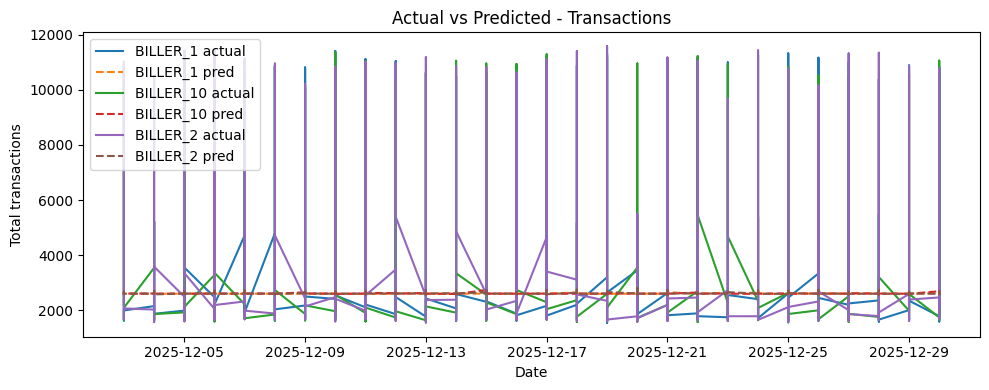

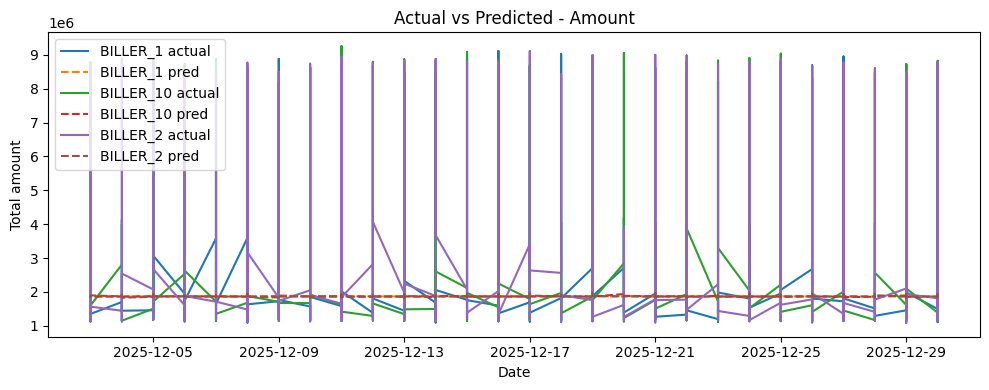

In [32]:
# PLOTS (matplotlib, one chart per figure)
sample_billers = results[biller_col].unique()[:3]
for metric, actual_col, pred_col, ylabel in [
    ("Transactions", 'actual_total_transactions', 'pred_total_transactions', 'Total transactions'),
    ("Amount", 'actual_total_amount', 'pred_total_amount', 'Total amount')
]:
    plt.figure(figsize=(10,4))
    for b in sample_billers:
        sub = results[results[biller_col] == b].sort_values(date_col)
        plt.plot(sub[date_col], sub[actual_col], label=f"{b} actual")
        plt.plot(sub[date_col], sub[pred_col], linestyle='--', label=f"{b} pred")
    plt.xlabel('Date')
    plt.ylabel(ylabel)
    plt.title(f'Actual vs Predicted - {metric}')
    plt.legend()
    plt.tight_layout()
    plt.show()

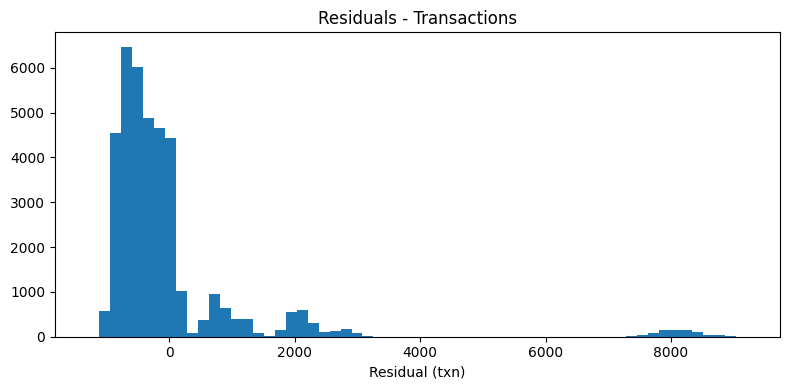

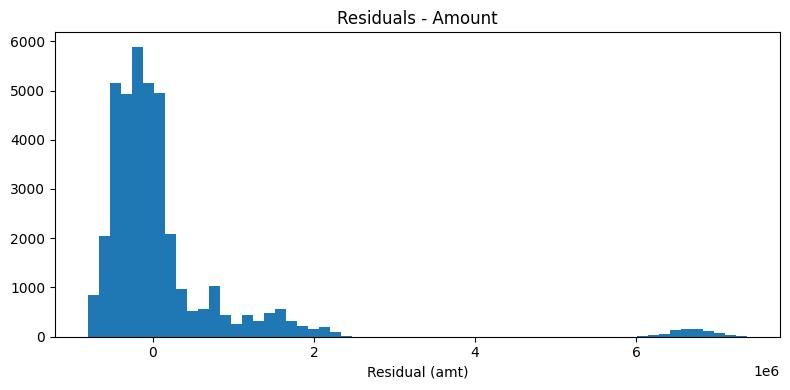

In [33]:
# Residuals histograms
plt.figure(figsize=(8,4)); plt.hist(results['error_txn'], bins=60); plt.xlabel('Residual (txn)'); plt.title('Residuals - Transactions'); plt.tight_layout(); plt.show()
plt.figure(figsize=(8,4)); plt.hist(results['error_amt'], bins=60); plt.xlabel('Residual (amt)'); plt.title('Residuals - Amount'); plt.tight_layout(); plt.show()


In [34]:
# Feature importance (gain) - top 20
def plot_fi(m, title):
    fi = pd.DataFrame({'feature': m.feature_name(), 'importance': m.feature_importance(importance_type='gain')})
    fi = fi.sort_values('importance', ascending=False).reset_index(drop=True)
    print(title)
    print(fi.head(20))
    plt.figure(figsize=(8,6)); plt.barh(fi['feature'].head(20)[::-1], fi['importance'].head(20)[::-1]); plt.title(title); plt.tight_layout(); plt.show()

Feature importance - Transactions
             feature    importance
0          biller_id  8.641533e+06
1         lag_txn_28  7.657842e+06
2          lag_amt_1  7.322867e+06
3         lag_amt_14  7.163285e+06
4          lag_txn_1  6.953363e+06
5         lag_amt_28  6.901026e+06
6         lag_txn_14  6.677176e+06
7          lag_amt_7  6.582334e+06
8          lag_txn_7  6.580056e+06
9    roll_amt_mean_7  6.187509e+06
10   roll_txn_std_14  5.653851e+06
11    roll_amt_std_7  5.602498e+06
12   roll_amt_std_14  5.519374e+06
13   roll_amt_std_30  5.473145e+06
14   roll_txn_mean_7  5.417858e+06
15    roll_txn_std_7  5.408430e+06
16  roll_amt_mean_30  5.334984e+06
17  roll_txn_mean_30  5.326180e+06
18   roll_txn_std_30  5.290931e+06
19  roll_amt_mean_14  5.022065e+06


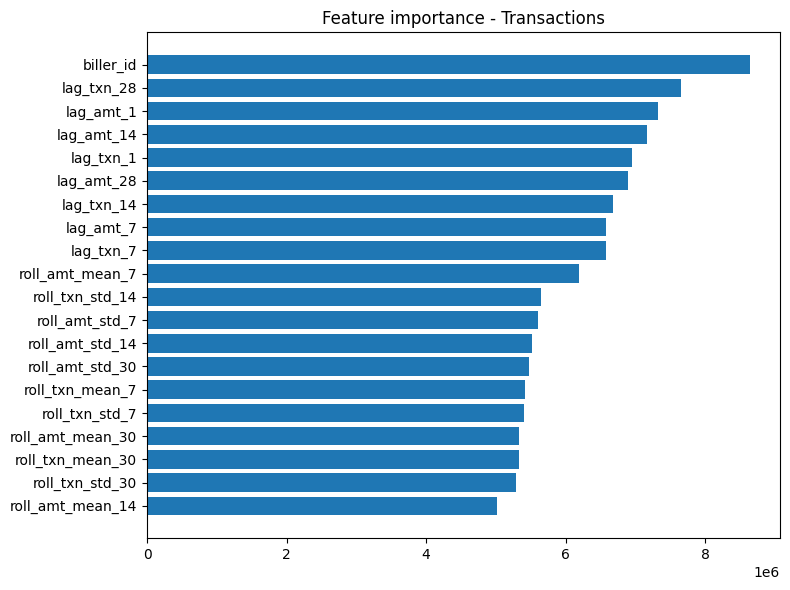

Feature importance - Amount
             feature   importance
0          biller_id  2214.796231
1         lag_amt_28  1941.233147
2         lag_txn_28  1877.270281
3          lag_amt_1  1852.724005
4         lag_txn_14  1804.716382
5          lag_txn_7  1790.603093
6          lag_amt_7  1788.369838
7          lag_txn_1  1775.995948
8         lag_amt_14  1745.386151
9     roll_amt_std_7  1628.381831
10   roll_amt_mean_7  1563.684403
11    roll_txn_std_7  1475.073902
12  roll_amt_mean_30  1458.696330
13   roll_txn_std_14  1450.124600
14   roll_txn_mean_7  1428.583997
15  roll_amt_mean_14  1423.578728
16   roll_txn_std_30  1402.517018
17   roll_amt_std_30  1389.822903
18   roll_amt_std_14  1380.080847
19  roll_txn_mean_14  1372.041823


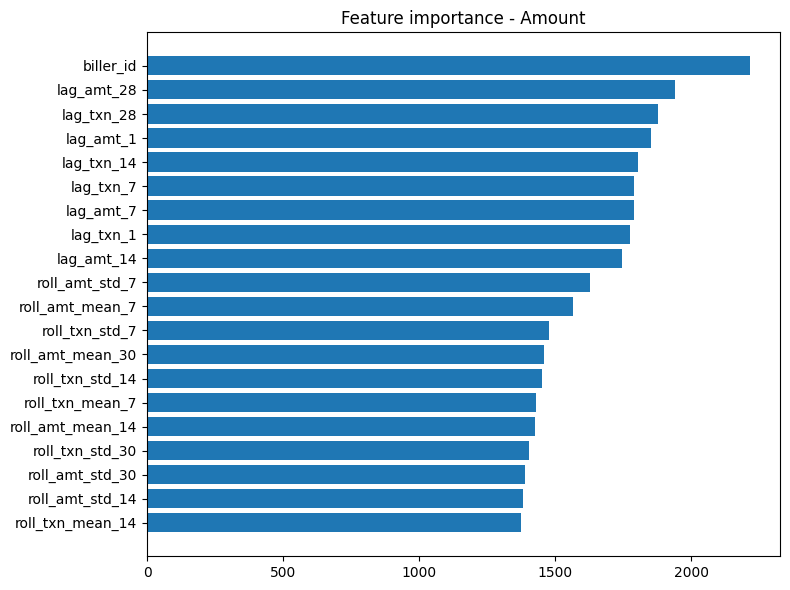

In [35]:
plot_fi(model_cnt, "Feature importance - Transactions")
plot_fi(model_amt, "Feature importance - Amount")